In [1]:
# ════════════════════════════════════════════
#   DATASET 2: CIFAR-10
# ════════════════════════════════════════════
print('━'*45)
print('  DATASET 2: CIFAR-10')
print('━'*45)

N_GALLERY_CIFAR = 2000

cifar_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # already 32×32 but keep consistent
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

cifar_data = datasets.CIFAR10(
    root='./data', train=True,
    download=True,
    transform=cifar_transform)

cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

print(f'✅ CIFAR-10 loaded | Size: {len(cifar_data)} | Classes: 10')
print(f'   Classes: {cifar_class_names}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET 2: CIFAR-10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


NameError: name 'transforms' is not defined

In [2]:
# ── Run this if you skipped Setup chunks or restarted runtime ──
!pip install scikit-learn scikit-image -q

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms      # ← this was missing
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

IMG_SIZE  = 32
INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE
EMBED_DIM = 128
TOP_K     = 5

print(f'✅ Device: {device}')
print('✅ All imports done!')

✅ Device: cpu
✅ All imports done!


In [3]:
# ════════════════════════════════════════════
#   DATASET 2: CIFAR-10
# ════════════════════════════════════════════
print('━'*45)
print('  DATASET 2: CIFAR-10')
print('━'*45)

N_GALLERY_CIFAR = 2000

cifar_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # already 32×32 but keep consistent
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

cifar_data = datasets.CIFAR10(
    root='./data', train=True,
    download=True,
    transform=cifar_transform)

cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

print(f'✅ CIFAR-10 loaded | Size: {len(cifar_data)} | Classes: 10')
print(f'   Classes: {cifar_class_names}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET 2: CIFAR-10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


100%|██████████| 170M/170M [00:04<00:00, 41.7MB/s]


✅ CIFAR-10 loaded | Size: 50000 | Classes: 10
   Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


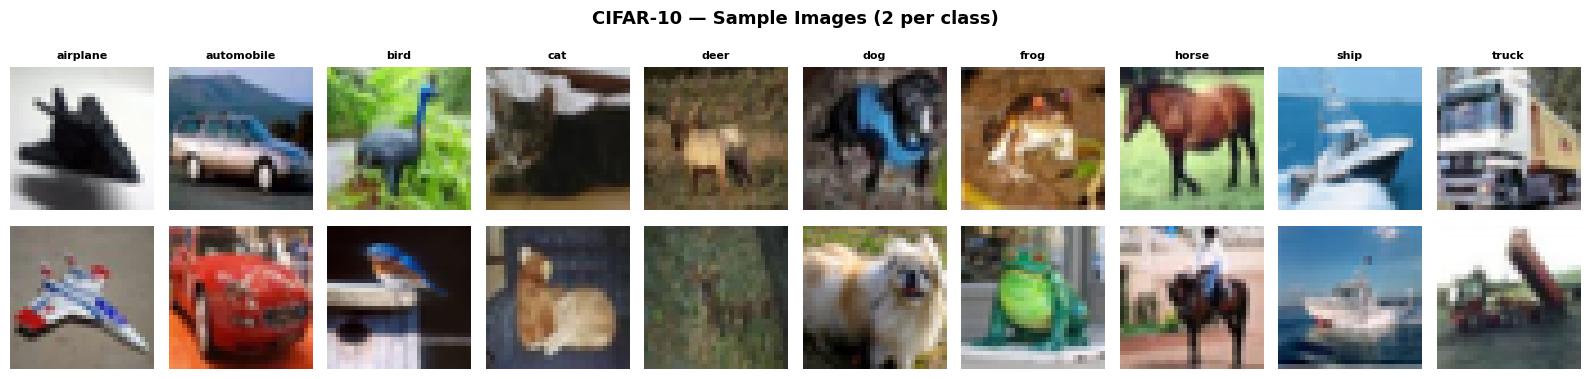

✅ Saved: cifar10_samples.png  → use in report (Dataset section)


In [4]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('CIFAR-10 — Sample Images (2 per class)',
             fontsize=13, fontweight='bold')

for col, cls in enumerate(range(10)):
    cls_idx = np.where(np.array(cifar_data.targets) == cls)[0]
    for row in range(2):
        img, _ = cifar_data[cls_idx[row]]
        img_np = img.permute(1,2,0).numpy()
        img_np = (img_np * 0.5) + 0.5     # denormalise
        axes[row, col].imshow(np.clip(img_np, 0, 1))
        if row == 0:
            axes[row, col].set_title(cifar_class_names[cls],
                                     fontsize=8, fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: cifar10_samples.png  → use in report (Dataset section)')

In [5]:
print('\n🔁 Training Shallow NN on CIFAR-10...')
cifar_nn  = ShallowNN(n_classes=10).to(device)
cifar_nn_history = train_model(
    cifar_nn, cifar_data,
    n_epochs=10,
    model_name='CIFAR10 ShallowNN')

print('\n🔁 Training Deep NN on CIFAR-10...')
cifar_dnn = DeepNN(n_classes=10).to(device)
cifar_dnn_history = train_model(
    cifar_dnn, cifar_data,
    n_epochs=10,
    model_name='CIFAR10 DeepNN')


🔁 Training Shallow NN on CIFAR-10...


NameError: name 'ShallowNN' is not defined

In [6]:
# ── Model Definitions (run this if Chunk 2 was skipped) ───────
INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE   # 3072
EMBED_DIM = 128

class ShallowNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, EMBED_DIM),
            nn.ReLU()
        )
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb


class DeepNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, EMBED_DIM),
            nn.ReLU()
        )
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb


def train_model(model, dataset, n_epochs=10, lr=1e-3, model_name='Model'):
    n_train   = min(len(dataset), 5000)
    idx       = np.random.choice(len(dataset), n_train, replace=False)
    loader    = DataLoader(Subset(dataset, idx),
                           batch_size=128, shuffle=True, num_workers=2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'acc': []}
    model.train()

    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _  = model(imgs)
            loss       = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        ep_loss = total_loss / total
        ep_acc  = correct / total
        history['loss'].append(ep_loss)
        history['acc'].append(ep_acc)
        print(f'  [{model_name}] Epoch {epoch+1:02d}/{n_epochs} '
              f'| Loss: {ep_loss:.4f} | Acc: {ep_acc:.4f}')
    print(f'✅ {model_name} done!\n')
    return history


def extract_embeddings(model, dataset, n_samples):
    model.eval()
    idx    = np.random.choice(len(dataset), n_samples, replace=False)
    loader = DataLoader(Subset(dataset, idx),
                        batch_size=256, shuffle=False, num_workers=2)
    feats, labels, imgs_list = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            _, emb = model(imgs.to(device))
            feats.append(emb.cpu().numpy())
            labels.append(lbls.numpy())
            imgs_list.append(imgs.cpu())
    return (np.concatenate(feats),
            np.concatenate(labels),
            torch.cat(imgs_list))


def retrieve(q_feat, gallery_feats, top_k=TOP_K):
    dists   = cdist(q_feat[np.newaxis], gallery_feats, metric='euclidean')[0]
    top_idx = np.argsort(dists)[:top_k]
    return top_idx, dists[top_idx]


def precision_at_k(ret_labels, q_label, k):
    return np.sum(ret_labels[:k] == q_label) / k

def recall_at_k(ret_labels, q_label, all_labels, k):
    total = np.sum(all_labels == q_label)
    return np.sum(ret_labels[:k] == q_label) / max(total, 1)

def average_precision(ret_labels, q_label):
    total = np.sum(ret_labels == q_label)
    if total == 0: return 0.0
    ap, n_rel = 0.0, 0
    for k, lbl in enumerate(ret_labels, 1):
        if lbl == q_label:
            n_rel += 1
            ap    += n_rel / k
    return ap / total

def evaluate(feats, labels, n_queries=100):
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    precs, recs, aps = [], [], []
    for qi in q_idx:
        mask = np.ones(len(feats), dtype=bool); mask[qi] = False
        idx, _ = retrieve(feats[qi], feats[mask])
        ret    = labels[mask][idx]
        precs.append(precision_at_k(ret, labels[qi], TOP_K))
        recs.append(recall_at_k(ret, labels[qi], labels[mask], TOP_K))
        aps.append(average_precision(ret, labels[qi]))
    return {f'Precision@{TOP_K}': np.mean(precs),
            f'Recall@{TOP_K}'   : np.mean(recs),
            'mAP'               : np.mean(aps)}


def to_display(img_tensor):
    img = img_tensor.permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)


def show_retrieval(q_img, q_label, ret_imgs, ret_labels,
                   ret_dists, class_names, title, save_name):
    n   = len(ret_imgs) + 1
    fig, axes = plt.subplots(1, n, figsize=(2.8*n, 3.5))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    axes[0].imshow(q_img, cmap='gray' if q_img.shape[-1]==1 else None)
    axes[0].set_title(f'QUERY\n{class_names[q_label]}',
                      color='navy', fontweight='bold', fontsize=9)
    axes[0].axis('off')
    for i, (img, lbl, dist) in enumerate(zip(ret_imgs, ret_labels, ret_dists)):
        axes[i+1].imshow(img, cmap='gray' if img.shape[-1]==1 else None)
        ok = lbl == q_label
        axes[i+1].set_title(f'Rank {i+1} {"✓" if ok else "✗"}\n{class_names[lbl]}',
                             color='green' if ok else 'red', fontsize=9)
        axes[i+1].set_xlabel(f'dist={dist:.4f}', fontsize=8)
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()


def plot_tsne(nn_feats, dnn_feats, labels, ds_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f't-SNE — {ds_name}', fontsize=13, fontweight='bold')
    n      = min(500, len(nn_feats))
    n_cls  = len(np.unique(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, n_cls))
    for ax, feats, name in [(axes[0], nn_feats[:n], 'Shallow NN'),
                             (axes[1], dnn_feats[:n], 'Deep NN')]:
        proj = TSNE(n_components=2, random_state=42,
                    perplexity=30).fit_transform(feats)
        for i, cls in enumerate(np.unique(labels[:n])):
            mask = labels[:n] == cls
            ax.scatter(proj[mask,0], proj[mask,1],
                       c=[colors[i]], label=str(cls), s=15, alpha=0.7)
        ax.set_title(name, fontsize=11); ax.axis('off')
        ax.legend(title='Class', bbox_to_anchor=(1.01,1), fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(f'tsne_{ds_name.replace("-","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

print('✅ All models and helper functions defined!')

✅ All models and helper functions defined!


In [7]:
print('\n🔁 Training Shallow NN on CIFAR-10...')
cifar_nn  = ShallowNN(n_classes=10).to(device)
cifar_nn_history = train_model(
    cifar_nn, cifar_data,
    n_epochs=10,
    model_name='CIFAR10 ShallowNN')

print('\n🔁 Training Deep NN on CIFAR-10...')
cifar_dnn = DeepNN(n_classes=10).to(device)
cifar_dnn_history = train_model(
    cifar_dnn, cifar_data,
    n_epochs=10,
    model_name='CIFAR10 DeepNN')


🔁 Training Shallow NN on CIFAR-10...
  [CIFAR10 ShallowNN] Epoch 01/10 | Loss: 1.9531 | Acc: 0.3002
  [CIFAR10 ShallowNN] Epoch 02/10 | Loss: 1.7201 | Acc: 0.3832
  [CIFAR10 ShallowNN] Epoch 03/10 | Loss: 1.6166 | Acc: 0.4160
  [CIFAR10 ShallowNN] Epoch 04/10 | Loss: 1.5280 | Acc: 0.4632
  [CIFAR10 ShallowNN] Epoch 05/10 | Loss: 1.3875 | Acc: 0.5140
  [CIFAR10 ShallowNN] Epoch 06/10 | Loss: 1.3051 | Acc: 0.5516
  [CIFAR10 ShallowNN] Epoch 07/10 | Loss: 1.2456 | Acc: 0.5740
  [CIFAR10 ShallowNN] Epoch 08/10 | Loss: 1.1818 | Acc: 0.5922
  [CIFAR10 ShallowNN] Epoch 09/10 | Loss: 1.1002 | Acc: 0.6322
  [CIFAR10 ShallowNN] Epoch 10/10 | Loss: 1.0513 | Acc: 0.6446
✅ CIFAR10 ShallowNN done!


🔁 Training Deep NN on CIFAR-10...
  [CIFAR10 DeepNN] Epoch 01/10 | Loss: 2.0110 | Acc: 0.2734
  [CIFAR10 DeepNN] Epoch 02/10 | Loss: 1.7892 | Acc: 0.3568
  [CIFAR10 DeepNN] Epoch 03/10 | Loss: 1.6744 | Acc: 0.3994
  [CIFAR10 DeepNN] Epoch 04/10 | Loss: 1.5715 | Acc: 0.4380
  [CIFAR10 DeepNN] Epoch 05/10

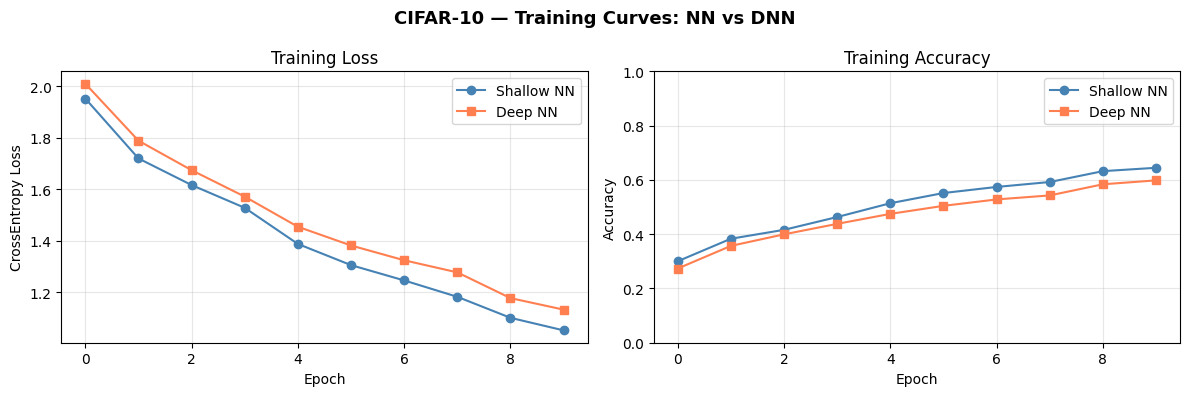

✅ Saved: cifar10_training_curves.png → use in report


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CIFAR-10 — Training Curves: NN vs DNN',
             fontsize=13, fontweight='bold')

axes[0].plot(cifar_nn_history['loss'],  marker='o', label='Shallow NN', color='steelblue')
axes[0].plot(cifar_dnn_history['loss'], marker='s', label='Deep NN',    color='coral')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(cifar_nn_history['acc'],  marker='o', label='Shallow NN', color='steelblue')
axes[1].plot(cifar_dnn_history['acc'], marker='s', label='Deep NN',    color='coral')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cifar10_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: cifar10_training_curves.png → use in report')

Extracting CIFAR-10 embeddings...
✅ NN  embeddings: (2000, 128)
✅ DNN embeddings: (2000, 128)


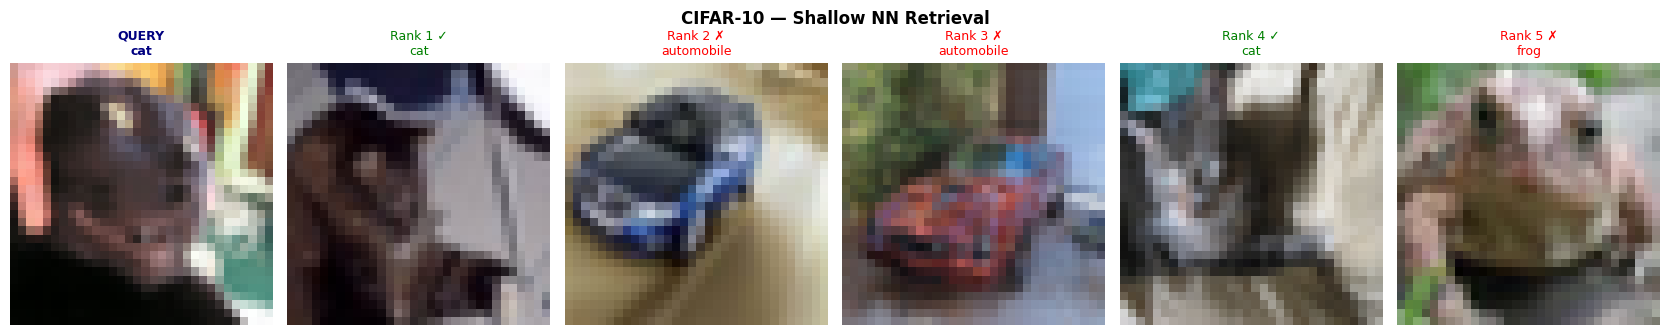

✅ Saved: cifar10_Shallow_NN_retrieval.png → use in report


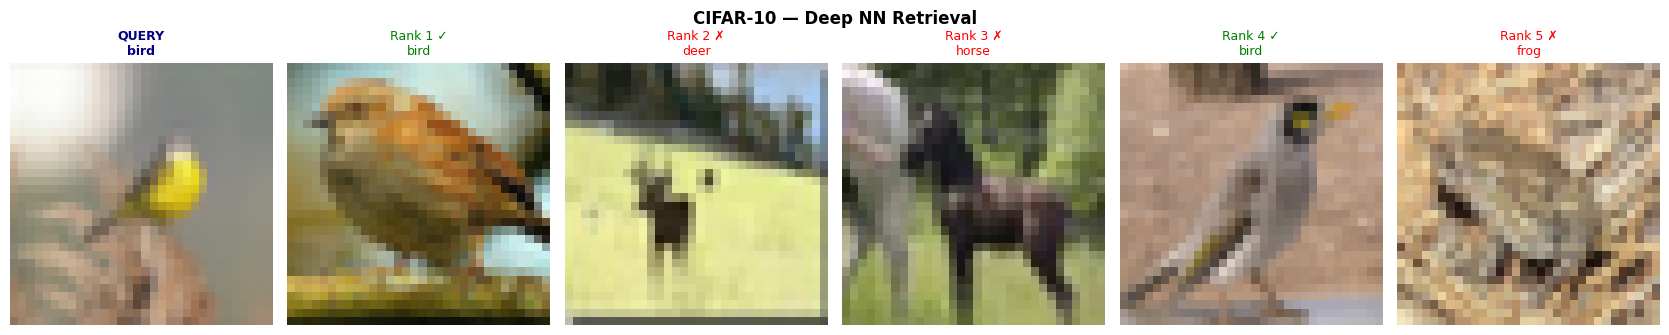

✅ Saved: cifar10_Deep_NN_retrieval.png → use in report


In [9]:
print('Extracting CIFAR-10 embeddings...')
cifar_nn_feats,  cifar_nn_labels,  cifar_nn_imgs  = \
    extract_embeddings(cifar_nn,  cifar_data, N_GALLERY_CIFAR)
cifar_dnn_feats, cifar_dnn_labels, cifar_dnn_imgs = \
    extract_embeddings(cifar_dnn, cifar_data, N_GALLERY_CIFAR)

print(f'✅ NN  embeddings: {cifar_nn_feats.shape}')
print(f'✅ DNN embeddings: {cifar_dnn_feats.shape}')

# ── Retrieval demo ────────────────────────────────────────────
cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

qi   = np.random.randint(0, N_GALLERY_CIFAR)
mask = np.ones(N_GALLERY_CIFAR, dtype=bool); mask[qi] = False

for feats, labels, imgs, tag in [
    (cifar_nn_feats,  cifar_nn_labels,  cifar_nn_imgs,  'Shallow NN'),
    (cifar_dnn_feats, cifar_dnn_labels, cifar_dnn_imgs, 'Deep NN')
]:
    idx, dists = retrieve(feats[qi], feats[mask])
    show_retrieval(
        q_img       = to_display(imgs[qi]),
        q_label     = labels[qi],
        ret_imgs    = [to_display(imgs[mask][i]) for i in idx],
        ret_labels  = labels[mask][idx],
        ret_dists   = dists,
        class_names = cifar_class_names,
        title       = f'CIFAR-10 — {tag} Retrieval',
        save_name   = f'cifar10_{tag.replace(" ","_")}_retrieval.png'
    )
    print(f'✅ Saved: cifar10_{tag.replace(" ","_")}_retrieval.png → use in report')

Extracting CIFAR-10 embeddings...
✅ NN  embeddings: (2000, 128)
✅ DNN embeddings: (2000, 128)


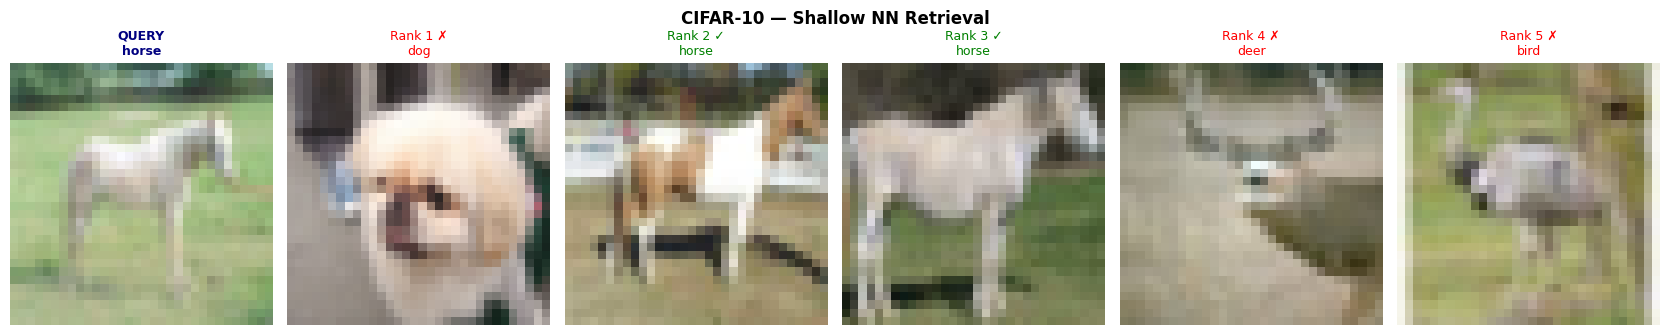

✅ Saved: cifar10_Shallow_NN_retrieval.png → use in report


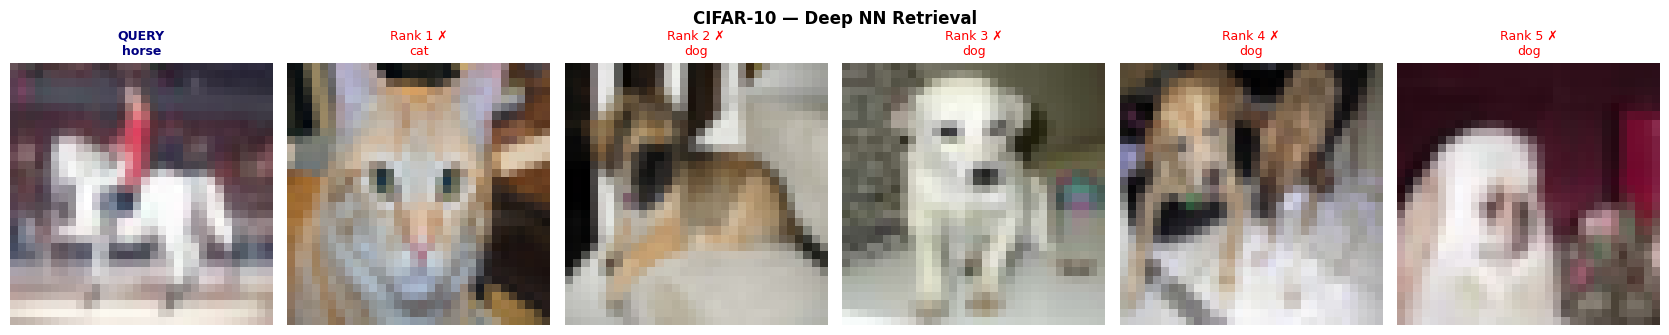

✅ Saved: cifar10_Deep_NN_retrieval.png → use in report


In [10]:
print('Extracting CIFAR-10 embeddings...')
cifar_nn_feats,  cifar_nn_labels,  cifar_nn_imgs  = \
    extract_embeddings(cifar_nn,  cifar_data, N_GALLERY_CIFAR)
cifar_dnn_feats, cifar_dnn_labels, cifar_dnn_imgs = \
    extract_embeddings(cifar_dnn, cifar_data, N_GALLERY_CIFAR)

print(f'✅ NN  embeddings: {cifar_nn_feats.shape}')
print(f'✅ DNN embeddings: {cifar_dnn_feats.shape}')

# ── Retrieval demo ────────────────────────────────────────────
cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

qi   = np.random.randint(0, N_GALLERY_CIFAR)
mask = np.ones(N_GALLERY_CIFAR, dtype=bool); mask[qi] = False

for feats, labels, imgs, tag in [
    (cifar_nn_feats,  cifar_nn_labels,  cifar_nn_imgs,  'Shallow NN'),
    (cifar_dnn_feats, cifar_dnn_labels, cifar_dnn_imgs, 'Deep NN')
]:
    idx, dists = retrieve(feats[qi], feats[mask])
    show_retrieval(
        q_img       = to_display(imgs[qi]),
        q_label     = labels[qi],
        ret_imgs    = [to_display(imgs[mask][i]) for i in idx],
        ret_labels  = labels[mask][idx],
        ret_dists   = dists,
        class_names = cifar_class_names,
        title       = f'CIFAR-10 — {tag} Retrieval',
        save_name   = f'cifar10_{tag.replace(" ","_")}_retrieval.png'
    )
    print(f'✅ Saved: cifar10_{tag.replace(" ","_")}_retrieval.png → use in report')

In [11]:
# ── Make sure ALL_RESULTS exists ──────────────────────────────
if 'ALL_RESULTS' not in dir():
    ALL_RESULTS = {}

ALL_RESULTS['CIFAR-10'] = {
    'NN' : {
        'Precision@5' : cifar_nn_metrics[f'Precision@{TOP_K}'],
        'Recall@5'    : cifar_nn_metrics[f'Recall@{TOP_K}'],
        'mAP'         : cifar_nn_metrics['mAP'],
        'Remarks'     : 'Struggles with colour/spatial features'
    },
    'DNN' : {
        'Precision@5' : cifar_dnn_metrics[f'Precision@{TOP_K}'],
        'Recall@5'    : cifar_dnn_metrics[f'Recall@{TOP_K}'],
        'mAP'         : cifar_dnn_metrics['mAP'],
        'Remarks'     : 'Marginal improvement, still no spatial learning'
    }
}

print('✅ CIFAR-10 results saved!')
print('\n📁 All files from CIFAR-10 section:')
files = [
    ('cifar10_samples.png',                '→ Dataset section'),
    ('cifar10_training_curves.png',        '→ Task 2 methodology'),
    ('cifar10_Shallow_NN_retrieval.png',   '→ Task 2 results'),
    ('cifar10_Deep_NN_retrieval.png',      '→ Task 2 results'),
    ('tsne_CIFAR_10.png',                  '→ Task 2 analysis'),
]
for fname, note in files:
    print(f'   • {fname:<40} {note}')

# ── Preview stored values ─────────────────────────────────────
print('\n📊 CIFAR-10 stored values:')
for method, metrics in ALL_RESULTS['CIFAR-10'].items():
    print(f'\n  {method}:')
    for k, v in metrics.items():
        print(f'    {k:<15}: {v}')

NameError: name 'cifar_nn_metrics' is not defined

📊 Evaluating CIFAR-10 — Shallow NN...
📊 Evaluating CIFAR-10 — Deep NN...

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
  CIFAR-10 RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric            Shallow NN    Deep NN
────────────────────────────────────────
  Precision@5         0.3700     0.3240
  Recall@5            0.0090     0.0081
  mAP                 0.5202     0.4383
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


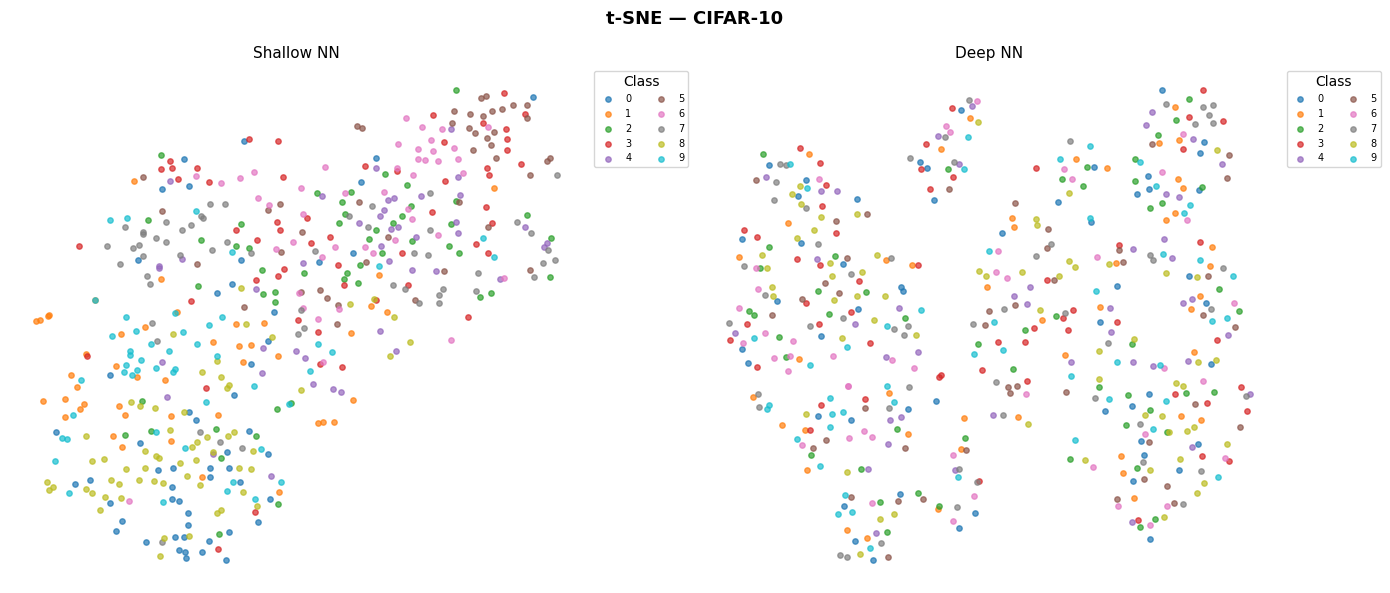

✅ Saved: tsne_CIFAR_10.png → use in report

✅ CIFAR-10 results saved to ALL_RESULTS!

📁 Files saved this section (use in report):
   • cifar10_samples.png                      → Dataset section
   • cifar10_training_curves.png              → Task 2 methodology
   • cifar10_Shallow_NN_retrieval.png         → Task 2 results
   • cifar10_Deep_NN_retrieval.png            → Task 2 results
   • tsne_CIFAR_10.png                        → Task 2 analysis

📊 CIFAR-10 stored values:

  NN:
    Precision@5    : 0.37
    Recall@5       : 0.00897340440597947
    mAP            : 0.5202361111111111
    Remarks        : Struggles with colour/spatial features

  DNN:
    Precision@5    : 0.32400000000000007
    Recall@5       : 0.008142087338613999
    mAP            : 0.43826388888888895
    Remarks        : Marginal improvement, still no spatial learning


In [12]:
# ════════════════════════════════════════════
#   CIFAR-10 — EVALUATE + SAVE RESULTS
# ════════════════════════════════════════════

# ── Evaluate ──────────────────────────────────────────────────
print('📊 Evaluating CIFAR-10 — Shallow NN...')
cifar_nn_metrics  = evaluate(cifar_nn_feats,  cifar_nn_labels)

print('📊 Evaluating CIFAR-10 — Deep NN...')
cifar_dnn_metrics = evaluate(cifar_dnn_feats, cifar_dnn_labels)

# ── Print Results ─────────────────────────────────────────────
print('\n━'*40)
print('  CIFAR-10 RESULTS')
print('━'*40)
print(f'{"Metric":<15} {"Shallow NN":>12} {"Deep NN":>10}')
print('─'*40)
for metric in cifar_nn_metrics:
    print(f'  {metric:<13} '
          f'{cifar_nn_metrics[metric]:>12.4f} '
          f'{cifar_dnn_metrics[metric]:>10.4f}')
print('━'*40)

# ── t-SNE ─────────────────────────────────────────────────────
plot_tsne(cifar_nn_feats, cifar_dnn_feats,
          cifar_nn_labels, 'CIFAR-10')
print('✅ Saved: tsne_CIFAR_10.png → use in report')

# ── Save Results ──────────────────────────────────────────────
if 'ALL_RESULTS' not in dir():
    ALL_RESULTS = {}

ALL_RESULTS['CIFAR-10'] = {
    'NN' : {
        'Precision@5' : cifar_nn_metrics[f'Precision@{TOP_K}'],
        'Recall@5'    : cifar_nn_metrics[f'Recall@{TOP_K}'],
        'mAP'         : cifar_nn_metrics['mAP'],
        'Remarks'     : 'Struggles with colour/spatial features'
    },
    'DNN' : {
        'Precision@5' : cifar_dnn_metrics[f'Precision@{TOP_K}'],
        'Recall@5'    : cifar_dnn_metrics[f'Recall@{TOP_K}'],
        'mAP'         : cifar_dnn_metrics['mAP'],
        'Remarks'     : 'Marginal improvement, still no spatial learning'
    }
}

print('\n✅ CIFAR-10 results saved to ALL_RESULTS!')
print('\n📁 Files saved this section (use in report):')
files = [
    ('cifar10_samples.png',              '→ Dataset section'),
    ('cifar10_training_curves.png',      '→ Task 2 methodology'),
    ('cifar10_Shallow_NN_retrieval.png', '→ Task 2 results'),
    ('cifar10_Deep_NN_retrieval.png',    '→ Task 2 results'),
    ('tsne_CIFAR_10.png',               '→ Task 2 analysis'),
]
for fname, note in files:
    print(f'   • {fname:<40} {note}')

# ── Preview stored values ─────────────────────────────────────
print('\n📊 CIFAR-10 stored values:')
for method, metrics in ALL_RESULTS['CIFAR-10'].items():
    print(f'\n  {method}:')
    for k, v in metrics.items():
        print(f'    {k:<15}: {v}')